In [2]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [4]:
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Linear(128, 1)
        self.bbox_head = nn.Linear(128, 4)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)

        obj_logit = self.classifier(x)
        bbox = torch.sigmoid(self.bbox_head(x))

        return obj_logit, bbox


In [5]:
model = PneumoniaCNN().to(device)
model.load_state_dict(
    torch.load(
        r"D:\Project\AI That Explains Medical Images Like a Doctor\Another way\model creation\pneumonia_cnn.pth",
        map_location=device
    )
)
model.eval()


C:\Users\deven\AppData\Local\Temp\ipykernel_16556\2933796981.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=128, out_features=1, bias=True)
  (bbox_head): Linear(in_features=128, out_features=4, bias=True)
)

In [6]:
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])


In [7]:
class XrayTestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples = []

        for label_name, label in [("normal", 0), ("pneumonia", 1)]:
            folder = os.path.join(root_dir, label_name)
            for img in os.listdir(folder):
                self.samples.append((
                    os.path.join(folder, img),
                    label,
                    img
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, img_name = self.samples[idx]

        image = Image.open(img_path).convert("RGB")
        orig_w, orig_h = image.size

        if self.transform:
            image = self.transform(image)

        return image, label, img_name, orig_w, orig_h


In [8]:
test_dir = r"D:\Project\AI That Explains Medical Images Like a Doctor\Dataset\chest_xray\test"

test_dataset = XrayTestDataset(
    root_dir=test_dir,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Total test images:", len(test_dataset))


Total test images: 624


In [8]:
y_true = []
y_pred = []

threshold = 0.35

with torch.no_grad():
    for images, labels, img_names, orig_w, orig_h in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        obj_logits, bboxes = model(images)

        probs = torch.sigmoid(obj_logits).squeeze(1)
        preds = (probs >= threshold).long()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


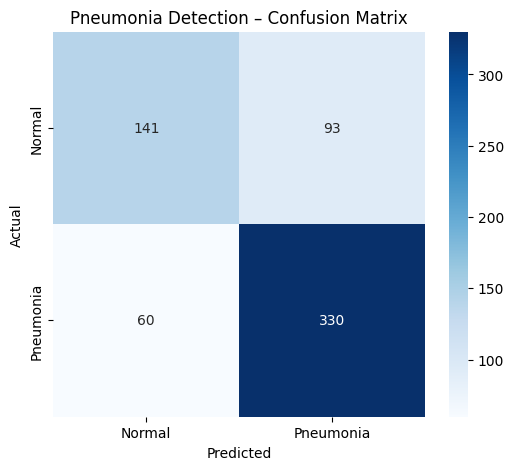

In [9]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Pneumonia"],
    yticklabels=["Normal", "Pneumonia"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Pneumonia Detection – Confusion Matrix")
plt.show()


In [10]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Pneumonia"]
    )
)


              precision    recall  f1-score   support

      Normal       0.70      0.60      0.65       234
   Pneumonia       0.78      0.85      0.81       390

    accuracy                           0.75       624
   macro avg       0.74      0.72      0.73       624
weighted avg       0.75      0.75      0.75       624



### precison recall threshhold

In [9]:
from sklearn.metrics import precision_score, recall_score

y_true = []
y_probs = []

with torch.no_grad():
    for images, labels, img_names, orig_w, orig_h in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        obj_logits, _ = model(images)
        probs = torch.sigmoid(obj_logits).squeeze(1)

        y_true.extend(labels.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_probs = np.array(y_probs)


In [10]:
thresholds = np.arange(0.1, 1.0, 0.1)

precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)

    precisions.append(precision)
    recalls.append(recall)

    print(f"Threshold {t:.1f} | Precision: {precision:.3f}, Recall: {recall:.3f}")


Threshold 0.1 | Precision: 0.624, Recall: 0.992
Threshold 0.2 | Precision: 0.637, Recall: 0.967
Threshold 0.3 | Precision: 0.726, Recall: 0.897
Threshold 0.4 | Precision: 0.820, Recall: 0.749
Threshold 0.5 | Precision: 0.951, Recall: 0.546
Threshold 0.6 | Precision: 1.000, Recall: 0.208
Threshold 0.7 | Precision: 0.000, Recall: 0.000
Threshold 0.8 | Precision: 0.000, Recall: 0.000
Threshold 0.9 | Precision: 0.000, Recall: 0.000


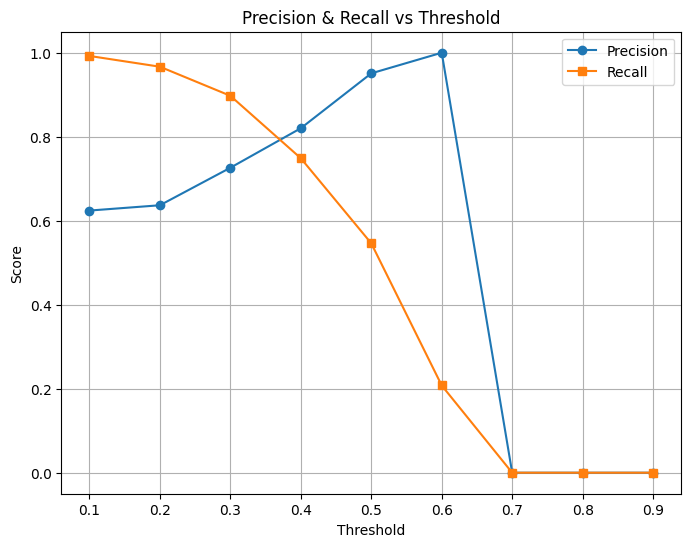

In [11]:
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions, marker='o', label="Precision")
plt.plot(thresholds, recalls, marker='s', label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
thresholds = np.arange(0.3, 0.4, 0.01)

precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)

    precisions.append(precision)
    recalls.append(recall)

    print(f"Threshold {t:.1f} | Precision: {precision:.3f}, Recall: {recall:.3f}")


Threshold 0.3 | Precision: 0.726, Recall: 0.897
Threshold 0.3 | Precision: 0.735, Recall: 0.890
Threshold 0.3 | Precision: 0.745, Recall: 0.882
Threshold 0.3 | Precision: 0.753, Recall: 0.869
Threshold 0.3 | Precision: 0.769, Recall: 0.854
Threshold 0.4 | Precision: 0.780, Recall: 0.846
Threshold 0.4 | Precision: 0.788, Recall: 0.831
Threshold 0.4 | Precision: 0.791, Recall: 0.808
Threshold 0.4 | Precision: 0.800, Recall: 0.790
Threshold 0.4 | Precision: 0.811, Recall: 0.772
Threshold 0.4 | Precision: 0.820, Recall: 0.749


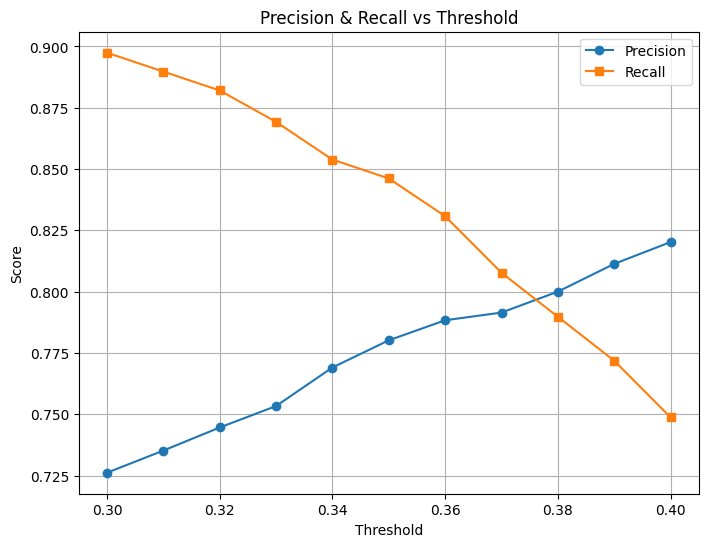

In [13]:
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions, marker='o', label="Precision")
plt.plot(thresholds, recalls, marker='s', label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()
